In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

/Users/chada/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
data_0 = pd.read_csv('All_data.csv')
data_0

,Unnamed: 0,# of A,# of B,# of X,W_A,EN_A,EA_A,1st IE_A,2nd IE_A,3rd IE_A,...,D_X,S_X,HV_X,t(AR),t(IR),u(AR),u(IR),Eg_ref,Eg_cal_cubic,Eg_cal_rhom
0,CsBaBr3,1,1,3,132.91,0.79,45.5,375.7,2234.3,3400.0,...,3120.0,947.3,14.8,0.80,0.82,2.69,0.69,5.14,5.14,5.14
1,CsBaCl3,1,1,3,132.91,0.79,45.5,375.7,2234.3,3400.0,...,2030.0,478.2,10.2,0.80,0.83,3.20,0.75,6.00,6.00,6.00
2,CsBaI3,1,1,3,132.91,0.79,45.5,375.7,2234.3,3400.0,...,4940.0,429.0,20.9,0.79,0.81,2.20,0.61,4.31,4.31,4.31
3,CsBeBr3,1,1,3,132.91,0.79,45.5,375.7,2234.3,3400.0,...,3120.0,947.3,14.8,1.35,1.13,1.19,0.23,2.01,2.01,2.01
4,CsBeCl3,1,1,3,132.91,0.79,45.5,375.7,2234.3,3400.0,...,2030.0,478.2,10.2,1.40,1.15,1.42,0.25,3.68,3.68,3.68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209,Cs4VCl6,4,1,6,132.91,0.79,45.5,375.7,2234.3,3400.0,...,2030.0,478.2,10.2,1.07,1.11,2.16,0.30,3.26,3.26,3.26
210,Cs4VI6,4,1,6,132.91,0.79,45.5,375.7,2234.3,3400.0,...,4940.0,429.0,20.9,1.02,1.05,1.49,0.25,3.46,3.46,3.46
211,Cs4ZnBr6,4,1,6,132.91,0.79,45.5,375.7,2234.3,3400.0,...,3120.0,947.3,14.8,1.17,1.01,1.51,0.38,4.37,4.37,4.37
212,Cs4ZnCl6,4,1,6,132.91,0.79,45.5,375.7,2234.3,3400.0,...,2030.0,478.2,10.2,1.21,1.02,1.80,0.41,5.47,5.47,5.47


In [3]:
data_1 = data_0.drop(columns=['Unnamed: 0'])

In [4]:
scaler = MinMaxScaler()
normalized_data_1 = pd.DataFrame(scaler.fit_transform(data_1), columns=data_1.columns)

In [5]:
normalized_data_1.var()

# of A          0.139385
# of B          0.244066
# of X          0.132624
W_A             0.086765
EN_A            0.024397
EA_A            0.031767
1st IE_A        0.030700
2nd IE_A        0.028669
3rd IE_A        0.024965
AR_A            0.043640
CR_A            0.032594
IR_A            0.043241
D_A             0.099769
S_A             0.039353
HV_A            0.030526
W_B             0.057622
EN_B            0.060503
EA_B            0.048394
1st IE_B        0.027497
2nd IE_B        0.034512
3rd IE_B        0.028631
AR_B            0.037572
CR_B            0.036770
IR_B            0.046309
D_B             0.024740
S_B             0.036241
HV_B            0.031522
OS_B            0.049388
W_X             0.158572
EN_X            0.156992
EA_X            0.157577
1st IE_X        0.157695
2nd IE_X        0.157175
3rd IE_X        0.161826
AR_X            0.157033
CR_X            0.157325
IR_X            0.157066
D_X             0.157173
S_X             0.204931
HV_X            0.157157


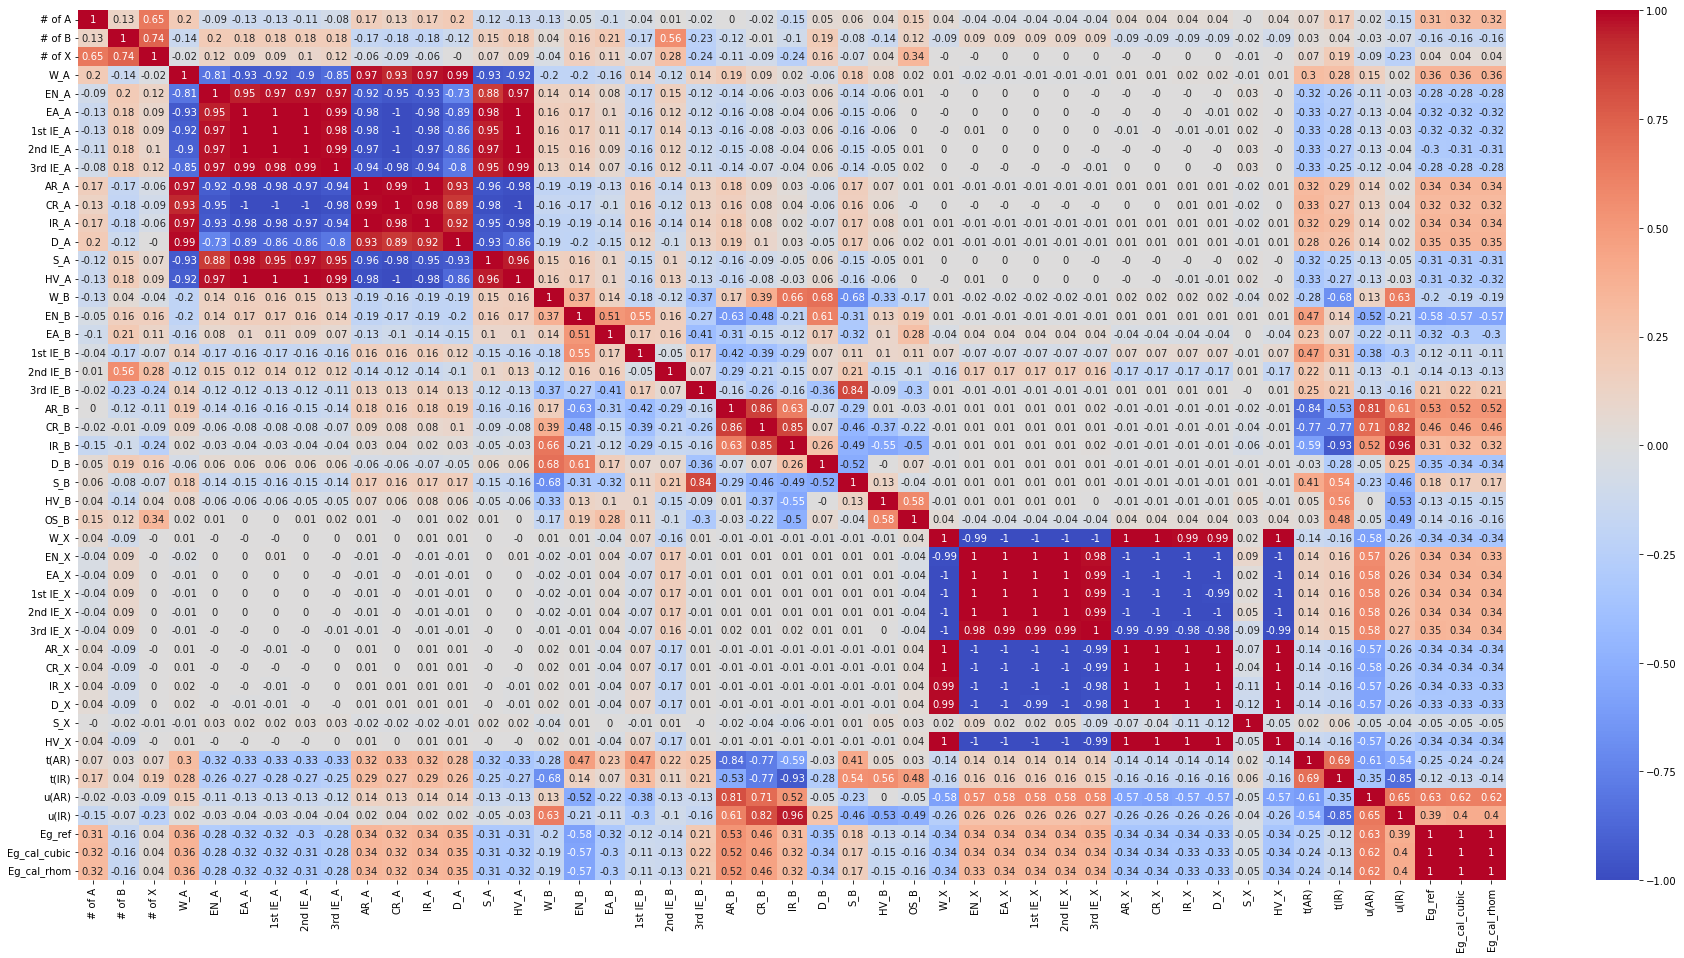

In [6]:
corr_1 = normalized_data_1.corr().round(2)
plt.figure(figsize=(32,16))
sns.heatmap(corr_1, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.savefig('corr_1.jpeg', format='jpeg', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
normalized_data_2 = normalized_data_1.drop(columns=['1st IE_A', '2nd IE_A', '3rd IE_A',
                                                    'AR_A', 'CR_A','IR_A', 'S_A', 
                                                    'HV_A', 'D_A', 'EA_A'])

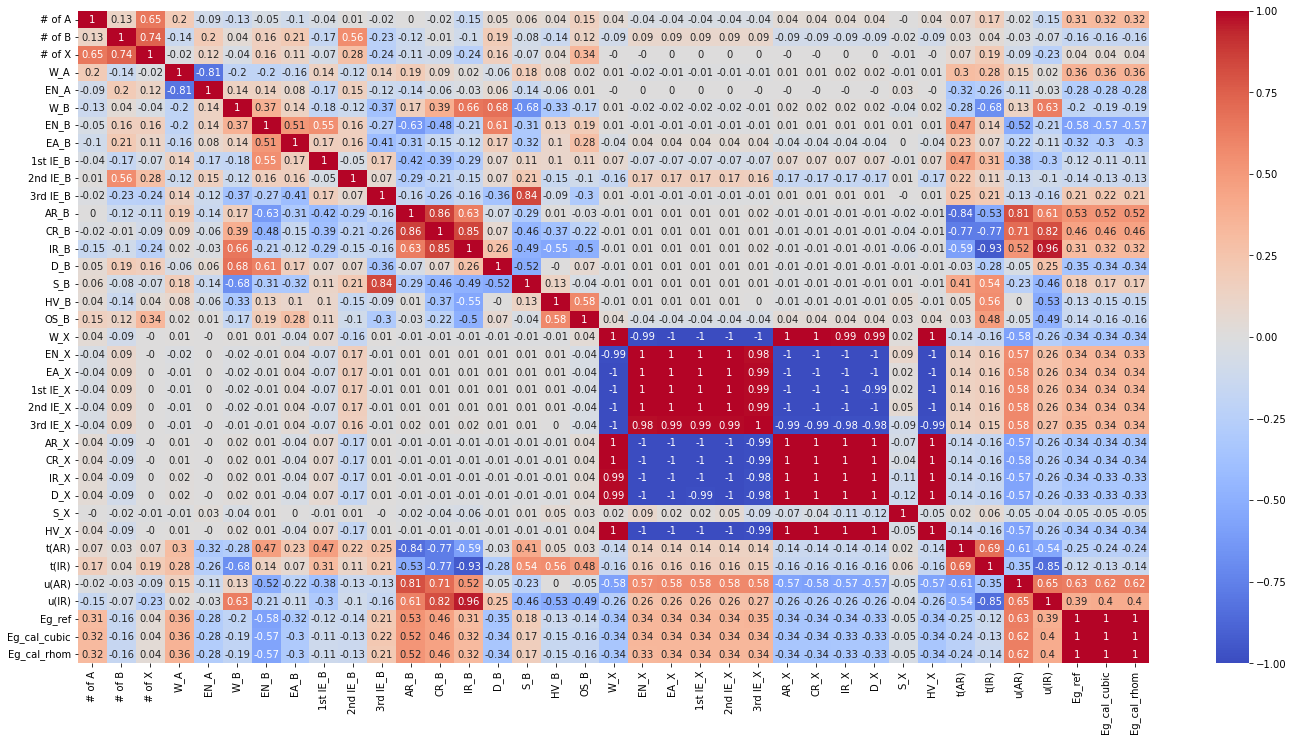

In [8]:
corr_2 = normalized_data_2.corr().round(2)
plt.figure(figsize=(24,12))
sns.heatmap(corr_2, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.savefig('corr_2.jpeg', format='jpeg', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
normalized_data_3 = normalized_data_2.drop(columns=['IR_B', '1st IE_X', '2nd IE_X', 
                                                    '3rd IE_X', 'AR_X', 'CR_X', 
                                                    'IR_X', 'EA_X', 'EN_X', 'D_X', 
                                                    'HV_X', 'u(AR)','AR_B', 'CR_B', 
                                                    'W_A', 'EN_A', 'OS_B', 't(IR)'])

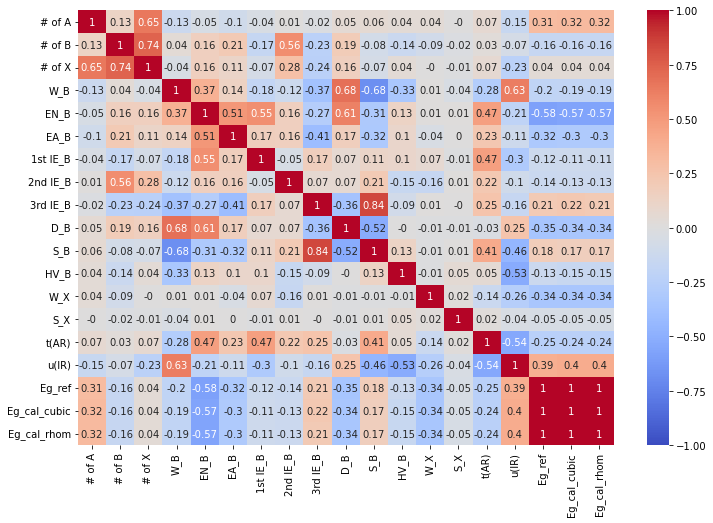

In [10]:
corr_3 = normalized_data_3.corr().round(2)
plt.figure(figsize=(12,8))
sns.heatmap(corr_3, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.savefig('corr_3.jpeg', format='jpeg', dpi=300, bbox_inches='tight')
plt.show()